# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [ ]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


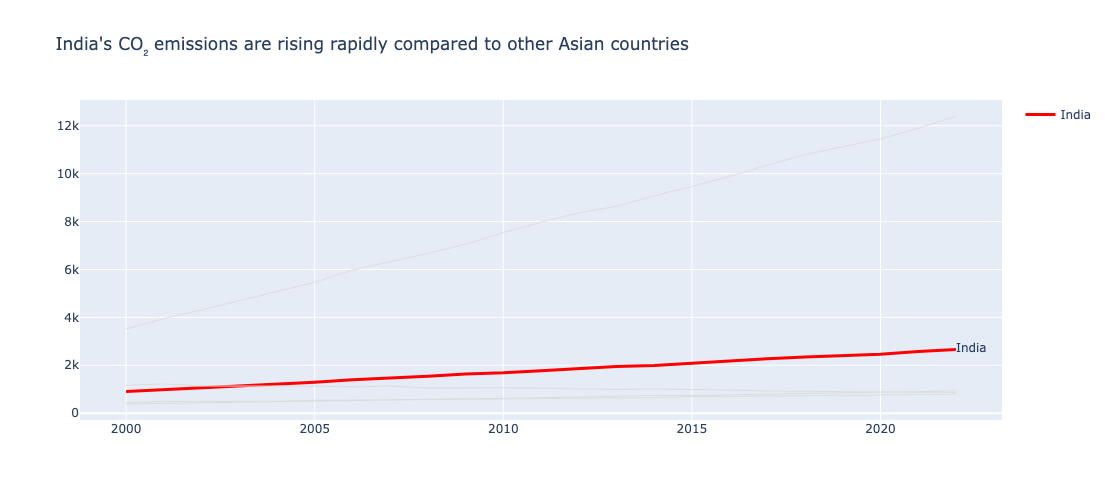

In [8]:
# Task 1 — Multi-series line with highlight
# YOUR CODE HERE


import plotly.graph_objects as go

# filter region (as hint suggests)
df_asia = df[df['Region'] == 'Asia']

highlight_country = 'India'

fig = go.Figure()

for country in df_asia['Country'].unique():
    country_df = df_asia[df_asia['Country'] == country]
    
    if country == highlight_country:
        fig.add_trace(go.Scatter(
            x=country_df['Year'],
            y=country_df['CO2_Mt'],
            mode='lines+text',
            name=country,
            line=dict(color='red', width=3),
            text=[None]*(len(country_df)-1) + [country],  # label only last point
            textposition='middle right'
        ))
    else:
        fig.add_trace(go.Scatter(
            x=country_df['Year'],
            y=country_df['CO2_Mt'],
            mode='lines',
            line=dict(color='#DDDDDD', width=1),
            showlegend=False
        ))

# Insight-driven title
fig.update_layout(
    title=f"{highlight_country}'s CO₂ emissions are rising rapidly compared to other Asian countries",
    height=500
)



fig.show()

In [11]:
df_region = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()

df_slope = df_region[df_region['Year'].isin([2000, 2022])]

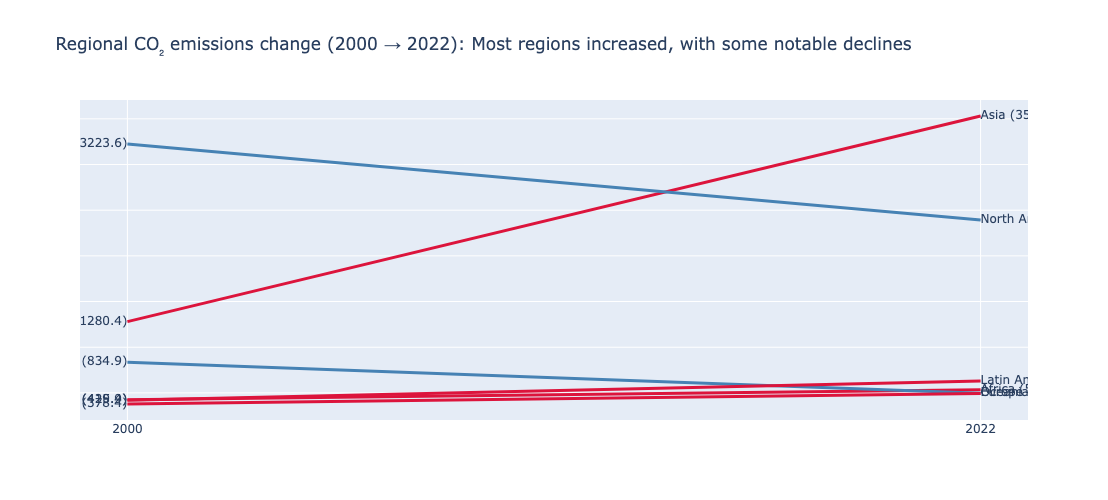

In [12]:
# Task 2 — Slopegraph: regional averages
# YOUR CODE HERE
import plotly.graph_objects as go

fig = go.Figure()

regions = df_slope['Region'].unique()

for region in regions:
    region_df = df_slope[df_slope['Region'] == region].sort_values('Year')
    
    y0 = region_df.iloc[0]['CO2_Mt']  # 2000
    y1 = region_df.iloc[1]['CO2_Mt']  # 2022
    
    color = 'crimson' if y1 > y0 else 'steelblue'
    
    fig.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[y0, y1],
        mode='lines+text',
        line=dict(color=color, width=3),
        showlegend=False,
        text=[f"{region} ({y0:.1f})", f"{region} ({y1:.1f})"],
        textposition=['middle left', 'middle right']
    ))

# layout styling
fig.update_layout(
    title="Regional CO₂ emissions change (2000 → 2022): Most regions increased, with some notable declines",
    height=500,
    xaxis=dict(
        tickvals=[2000, 2022],
        ticktext=['2000', '2022']
    ),
    yaxis=dict(
        showticklabels=False  # remove y-axis labels
    )
)

fig.show()


---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022
